In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from scripts.plotting import *
from scripts.TPS import *

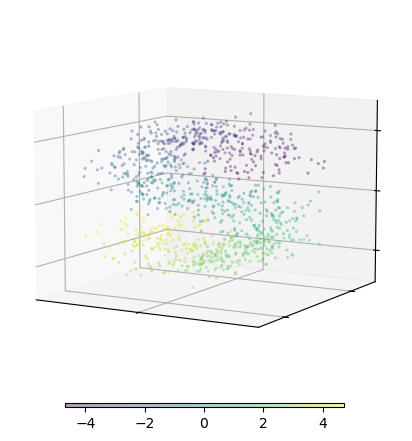

In [3]:
X_gt = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_gt_position_matrix.csv"))
Y_gt = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_gt_velocity_matrix.csv"))
t = pd.read_csv("./data/s_curve/uniform/s_curve_gt_latent_time_vector.csv")
col = list(t["t"])

plot_3d(X_gt, t)

In [4]:
from sklearn.neighbors import NearestNeighbors

def jaccard_knn_similarity(X_high, X_low, k=30):
    """
    Computes average Jaccard similarity between k-nearest neighbor sets
    in high-dimensional and low-dimensional spaces.

    Parameters:
        X_high (array-like): Original high-dimensional data (n_samples x n_features)
        X_low (array-like): Embedded low-dimensional data (n_samples x n_components)
        k (int): Number of neighbors to consider (excluding self)

    Returns:
        float: Average Jaccard similarity across all points
    """
    # Fit nearest neighbors
    nn_high = NearestNeighbors(n_neighbors=k+1).fit(X_high)
    nn_low = NearestNeighbors(n_neighbors=k+1).fit(X_low)

    knn_high = nn_high.kneighbors(return_distance=False)[:, 1:]  # skip self
    knn_low = nn_low.kneighbors(return_distance=False)[:, 1:]

    # Compute Jaccard similarity for each point
    jaccard_scores = []
    for i in range(X_high.shape[0]):
        set_high = set(knn_high[i])
        set_low = set(knn_low[i])
        intersection = len(set_high & set_low)
        union = len(set_high | set_low)
        jaccard_scores.append(intersection / union if union > 0 else 0.0)

    return np.mean(jaccard_scores)

/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


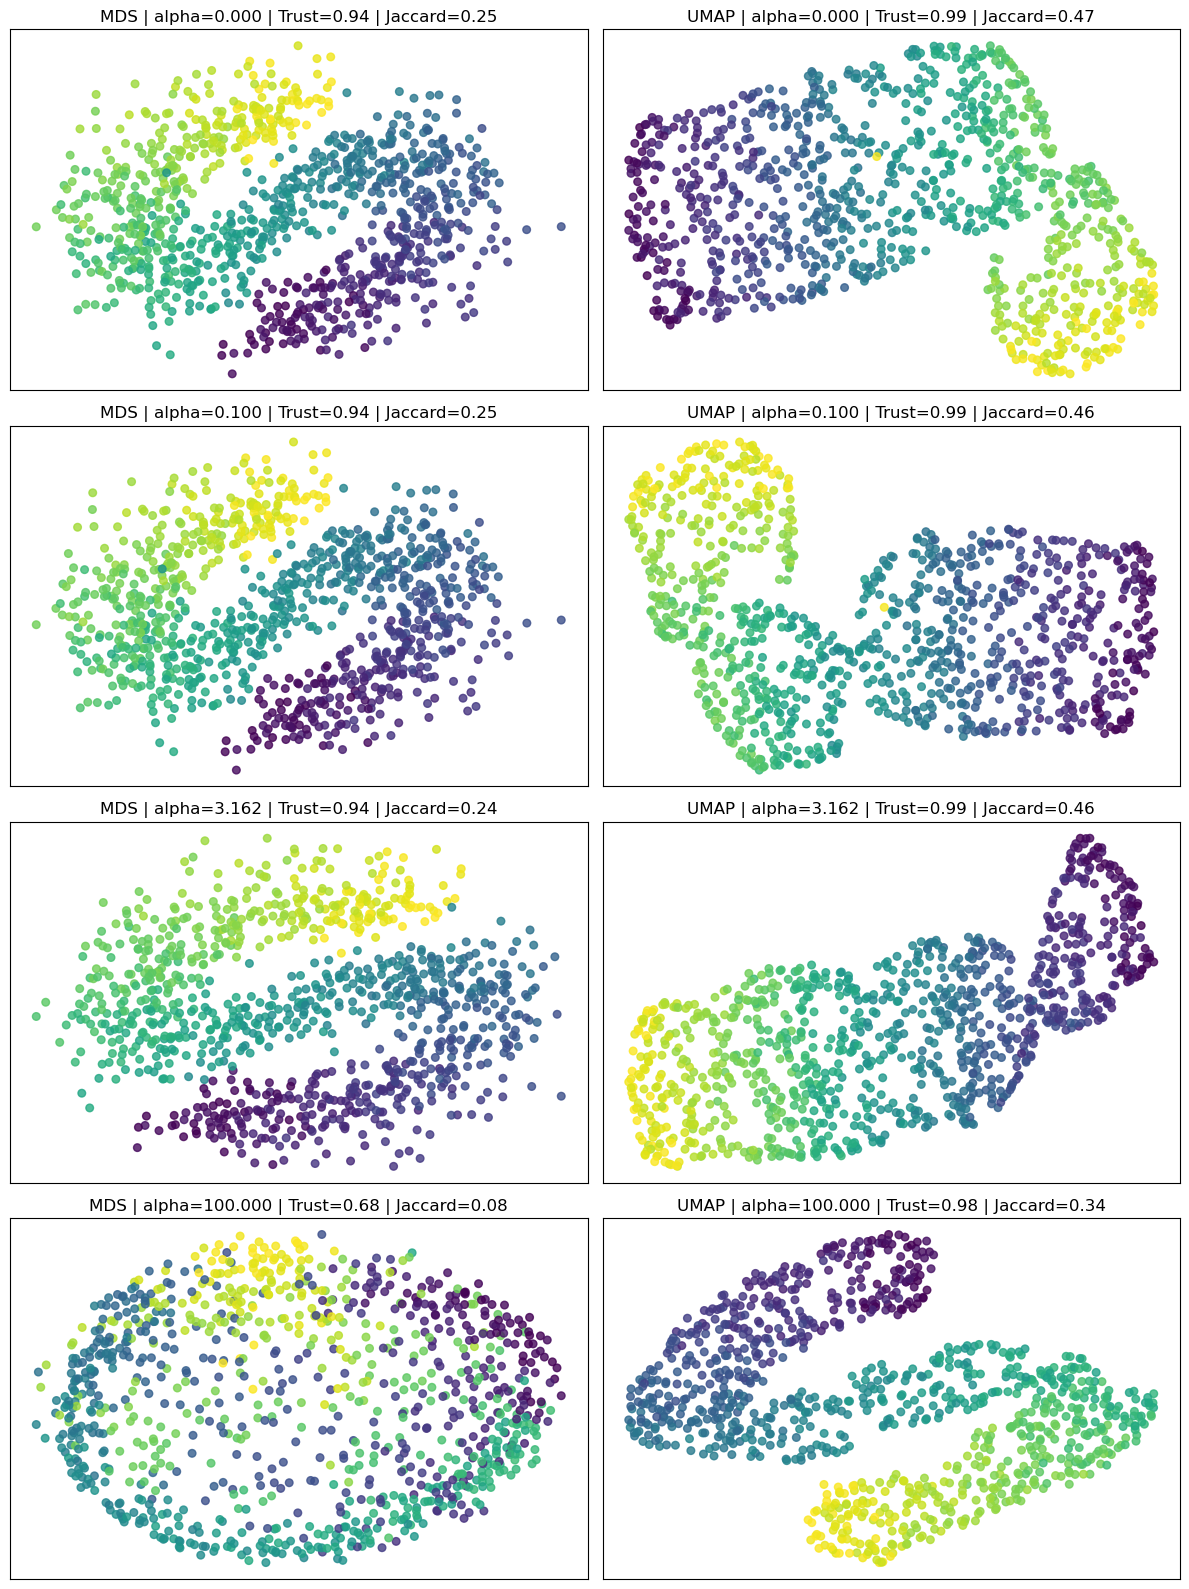

In [5]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.manifold import MDS
from sklearn.manifold import trustworthiness
from scipy.spatial.distance import cdist

from scripts.perturbation_distance import PerturbDistanceSolver
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap.umap_")

# ------------------------------------------------------------------------------
# Set up the solver & time-l2 operation
# ------------------------------------------------------------------------------
X_noise_std = 1e-3
Y_noise_std = 1e-3

X = X_gt + np.random.normal(scale=X_noise_std, size=X_gt.shape)
Y = Y_gt + np.random.normal(scale=Y_noise_std, size=Y_gt.shape)

# Standardize to mean 0, std 1
X = (X - X.mean(axis=0)) / X.std(axis=0)
Y = (Y - Y.mean(axis=0)) / Y.std(axis=0)

solver = PerturbDistanceSolver(X, Y)
t_dist = solver.pairwise_time_constrained_L2_distance()
neighbors = 20

# ------------------------------------------------------------------------------
# Define the range of betas on a log scale
# ------------------------------------------------------------------------------
alphas = np.logspace(-1, 2, 3)  # [0.01, ... , 1.0]
alphas = np.concatenate(([0], alphas))
dist_mat_sq = cdist(X, X, metric='sqeuclidean')

fig, axes = plt.subplots(nrows=len(alphas), ncols=2, figsize=(12, 4 * len(alphas)))
for i, alpha in enumerate(alphas):
    dist_mat = np.sqrt(dist_mat_sq + alpha * t_dist ** 2)
    
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    coords_mds = mds.fit_transform(dist_mat)
    
    trust_mds = trustworthiness(X_gt, coords_mds, n_neighbors=neighbors)
    jaccard_mds = jaccard_knn_similarity(X_gt, coords_mds, k=neighbors)
    ax_mds = axes[i, 0]  # left column for MDS
    sc_mds = ax_mds.scatter(coords_mds[:, 0], coords_mds[:, 1],
                            c=col, s=30, alpha=0.8, cmap='viridis')
    ax_mds.set_title(f"MDS | alpha={alpha:.3f} | Trust={trust_mds:.2f} | Jaccard={jaccard_mds:.2f}")
    ax_mds.set_xticks([])
    ax_mds.set_yticks([])
    ax_mds.grid(True)
    
    # -----------------------------------------------------
    # 3. UMAP with precomputed distances
    # -----------------------------------------------------
    reducer = umap.UMAP(
        n_neighbors=neighbors,
        n_components=2,
        metric="precomputed",
        min_dist = 0.6,
        random_state=1
    )
    coords_umap = reducer.fit_transform(dist_mat)
    
    trust_umap = trustworthiness(X_gt, coords_umap, n_neighbors=neighbors)
    jaccard_umap = jaccard_knn_similarity(X_gt, coords_umap, k=neighbors)
    ax_umap = axes[i, 1]  # right column for UMAP
    sc_umap = ax_umap.scatter(coords_umap[:, 0], coords_umap[:, 1],
                              c=col, s=30, alpha=0.8, cmap='viridis')
    ax_umap.set_title(f"UMAP | alpha={alpha:.3f} | Trust={trust_umap:.2f} | Jaccard={jaccard_umap:.2f}")
    ax_umap.set_xticks([])
    ax_umap.set_yticks([])
    ax_umap.grid(True)

plt.tight_layout()
plt.show()

/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


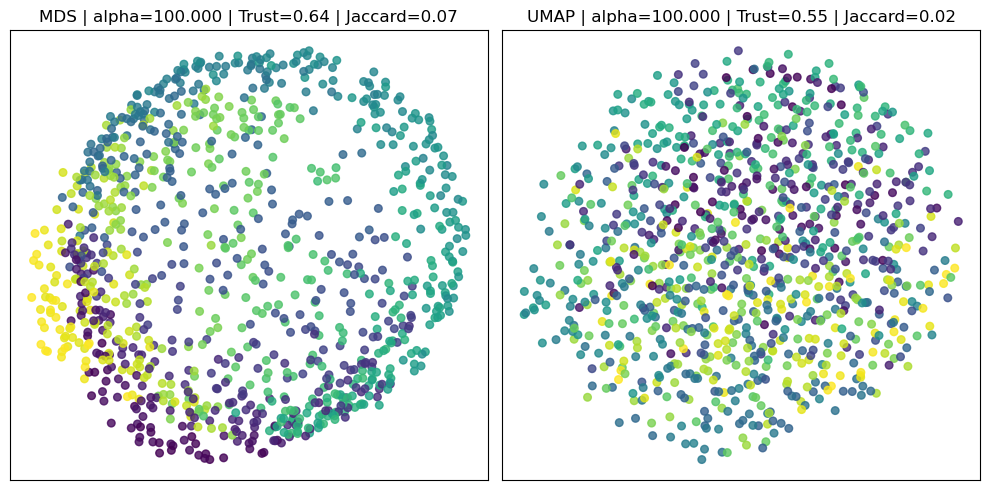

In [6]:
# Create subplot grid
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- MDS plot ---
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords_mds = mds.fit_transform(t_dist)

trust_mds = trustworthiness(X_gt, coords_mds, n_neighbors=neighbors)
jaccard_mds = jaccard_knn_similarity(X_gt, coords_mds, k=neighbors)
ax_mds = axes[0]
sc_mds = ax_mds.scatter(coords_mds[:, 0], coords_mds[:, 1],
                        c=col, s=30, alpha=0.8, cmap='viridis')
ax_mds.set_title(f"MDS | alpha={alpha:.3f} | Trust={trust_mds:.2f} | Jaccard={jaccard_mds:.2f}")
ax_mds.set_xticks([])
ax_mds.set_yticks([])
ax_mds.grid(True)

# --- UMAP plot ---
reducer = umap.UMAP(
    n_neighbors=10,
    n_components=2,
    metric="precomputed",
    min_dist=0.6,
    random_state=1
)
coords_umap = reducer.fit_transform(t_dist)

trust_umap = trustworthiness(X_gt, coords_umap, n_neighbors=neighbors)
jaccard_umap = jaccard_knn_similarity(X_gt, coords_umap, k=neighbors)
ax_umap = axes[1]
sc_umap = ax_umap.scatter(coords_umap[:, 0], coords_umap[:, 1],
                          c=col, s=30, alpha=0.8, cmap='viridis')
ax_umap.set_title(f"UMAP | alpha={alpha:.3f} | Trust={trust_umap:.2f} | Jaccard={jaccard_umap:.2f}")
ax_umap.set_xticks([])
ax_umap.set_yticks([])
ax_umap.grid(True)

plt.tight_layout()
plt.show()

/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


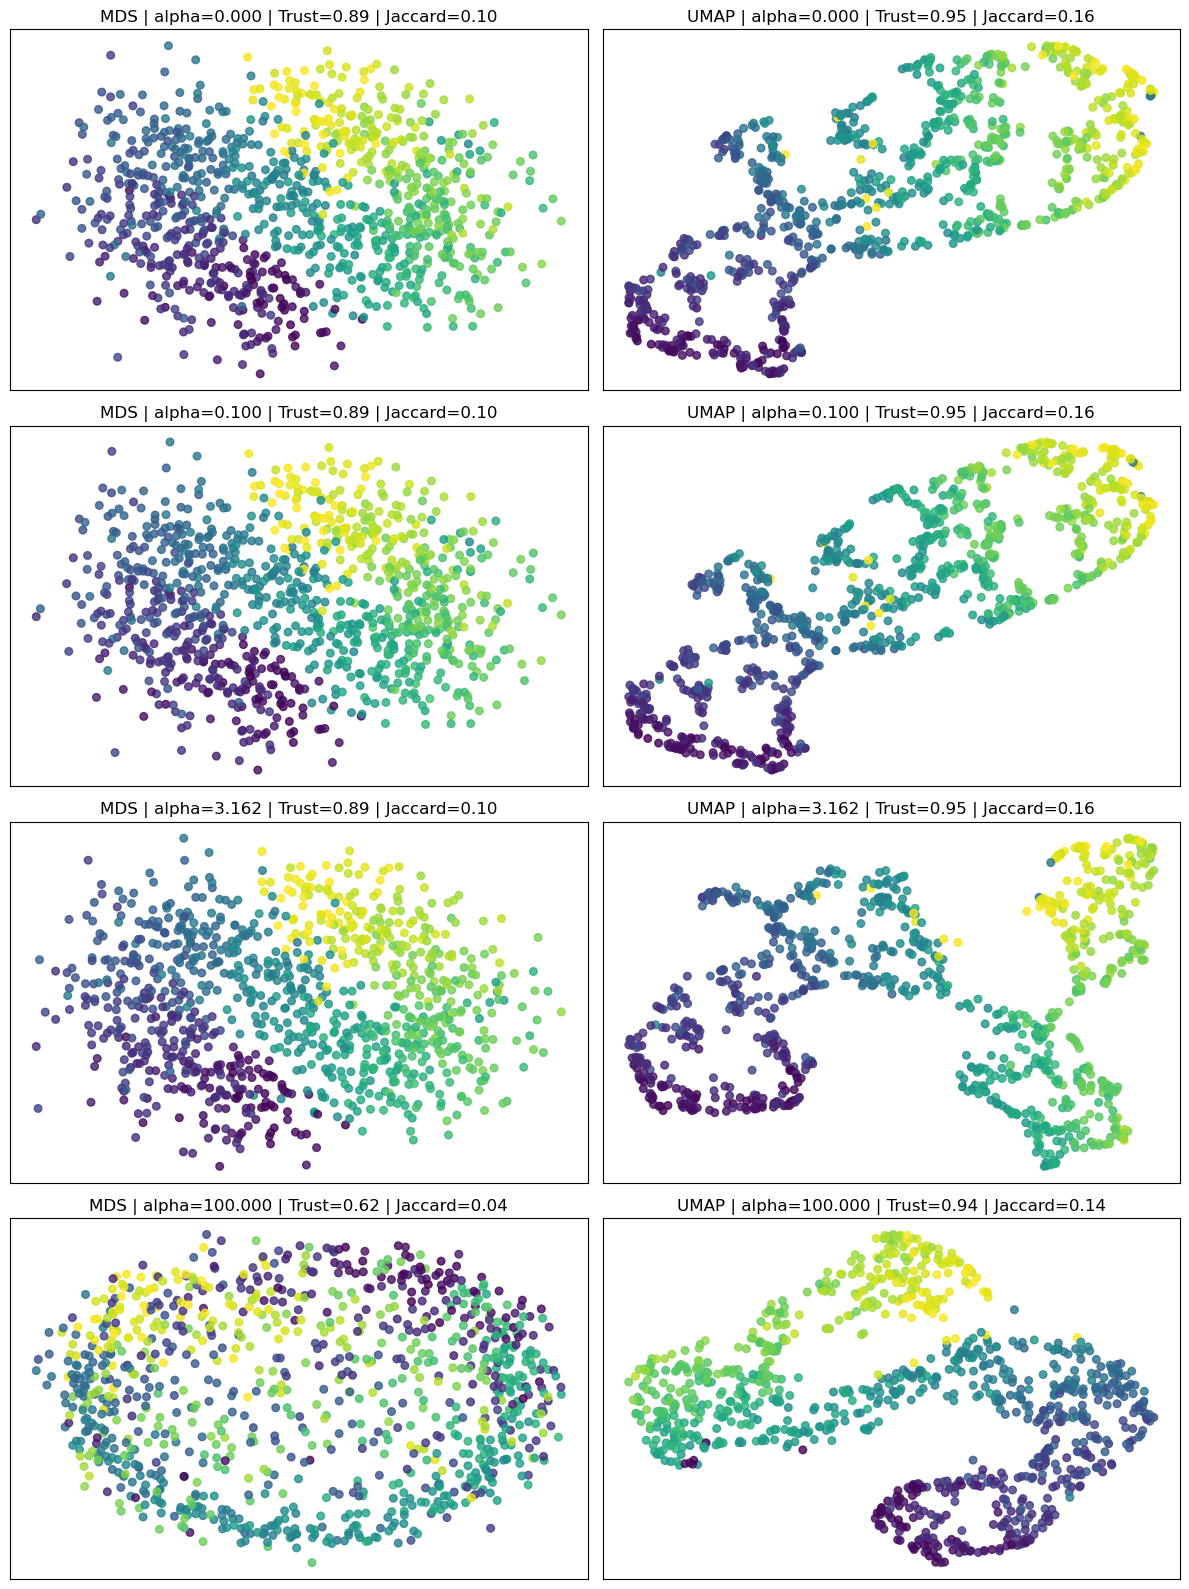

In [7]:
X_noise_std = 0.3
Y_noise_std = 0.3
neighbors = 20
# Get shape
n_samples = X_gt.shape[0]

# Add Gaussian noise to original 3D data
X = X_gt + np.random.normal(scale=X_noise_std, size=X_gt.shape)
Y = Y_gt + np.random.normal(scale=Y_noise_std, size=Y_gt.shape)

# Standardize to mean 0, std 1
X = (X - X.mean(axis=0)) / X.std(axis=0)
Y = (Y - Y.mean(axis=0)) / Y.std(axis=0)

solver = PerturbDistanceSolver(X, Y, quantile=0.5)
t_dist = solver.pairwise_time_constrained_L2_distance()

# ------------------------------------------------------------------------------
# Define the range of betas on a log scale
# ------------------------------------------------------------------------------
alphas = np.logspace(-1, 2, 3)
alphas = np.concatenate(([0], alphas))
dist_mat_sq = cdist(X, X, metric='sqeuclidean')

fig, axes = plt.subplots(nrows=len(alphas), ncols=2, figsize=(12, 4 * len(alphas)))
for i, alpha in enumerate(alphas):
    dist_mat = np.sqrt(dist_mat_sq + alpha * t_dist ** 2)
    
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    coords_mds = mds.fit_transform(dist_mat)
    
    trust_mds = trustworthiness(X_gt, coords_mds, n_neighbors=neighbors)
    jaccard_mds = jaccard_knn_similarity(X_gt, coords_mds, k=neighbors)
    ax_mds = axes[i, 0] 
    sc_mds = ax_mds.scatter(coords_mds[:, 0], coords_mds[:, 1],
                            c=col, s=30, alpha=0.8, cmap='viridis')
    ax_mds.set_title(f"MDS | alpha={alpha:.3f} | Trust={trust_mds:.2f} | Jaccard={jaccard_mds:.2f}")
    ax_mds.set_xticks([])
    ax_mds.set_yticks([])
    ax_mds.grid(True)
    
    # -----------------------------------------------------
    # 3. UMAP with precomputed distances
    # -----------------------------------------------------
    reducer = umap.UMAP(
        n_neighbors=neighbors,
        n_components=2,
        metric="precomputed",
#         min_dist = 0.4,
        random_state=1
    )
    coords_umap = reducer.fit_transform(dist_mat)
    
    trust_umap = trustworthiness(X_gt, coords_umap, n_neighbors=neighbors)
    jaccard_umap = jaccard_knn_similarity(X_gt, coords_umap, k=neighbors)
    
    ax_umap = axes[i, 1]  # right column for UMAP
    sc_umap = ax_umap.scatter(coords_umap[:, 0], coords_umap[:, 1],
                              c=col, s=30, alpha=0.8, cmap='viridis')
    ax_umap.set_title(f"UMAP | alpha={alpha:.3f} | Trust={trust_umap:.2f} | Jaccard={jaccard_umap:.2f}")
    ax_umap.set_xticks([])
    ax_umap.set_yticks([])
    ax_umap.grid(True)

plt.tight_layout()
plt.show()

/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


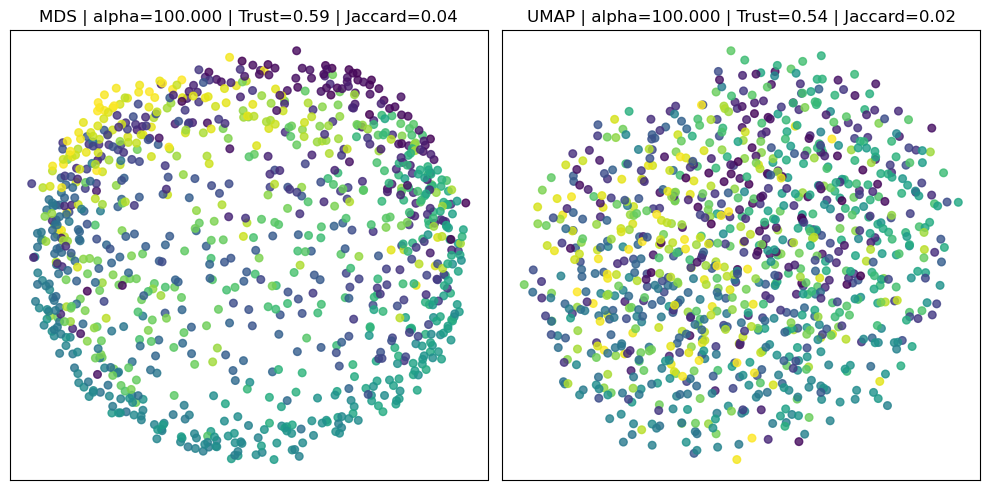

In [8]:
# Create subplot grid
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- MDS plot ---
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords_mds = mds.fit_transform(t_dist)

trust_mds = trustworthiness(X_gt, coords_mds, n_neighbors=neighbors)
jaccard_mds = jaccard_knn_similarity(X_gt, coords_mds, k=neighbors)
ax_mds = axes[0]
sc_mds = ax_mds.scatter(coords_mds[:, 0], coords_mds[:, 1],
                        c=col, s=30, alpha=0.8, cmap='viridis')
ax_mds.set_title(f"MDS | alpha={alpha:.3f} | Trust={trust_mds:.2f} | Jaccard={jaccard_mds:.2f}")
ax_mds.set_xticks([])
ax_mds.set_yticks([])
ax_mds.grid(True)

# --- UMAP plot ---
reducer = umap.UMAP(
    n_neighbors=10,
    n_components=2,
    metric="precomputed",
    min_dist=0.6,
    random_state=1
)
coords_umap = reducer.fit_transform(t_dist)

trust_umap = trustworthiness(X_gt, coords_umap, n_neighbors=neighbors)
jaccard_umap = jaccard_knn_similarity(X_gt, coords_umap, k=neighbors)
ax_umap = axes[1]
sc_umap = ax_umap.scatter(coords_umap[:, 0], coords_umap[:, 1],
                          c=col, s=30, alpha=0.8, cmap='viridis')
ax_umap.set_title(f"UMAP | alpha={alpha:.3f} | Trust={trust_umap:.2f} | Jaccard={jaccard_umap:.2f}")
ax_umap.set_xticks([])
ax_umap.set_yticks([])
ax_umap.grid(True)

plt.tight_layout()
plt.show()